# Assignment 2: RNA Secondary Structure Prediction with CNNs

**Name:** [Your Name Here]

**Student ID:** [Your Student ID Here]

## 1. Introduction & Objectives

Welcome to the second assignment! The goal of this assignment is not to build a state-of-the-art model, but to walk you through the complete pipeline of a deep learning project in bioinformatics. You will learn to process biological sequence data, convert it into a format suitable for neural networks, build a basic CNN model, and critically analyze its results.

### Core Learning Objectives:
1.  Understand and process standard bioinformatics data formats (FASTA and dot-bracket notation).
2.  Master data encoding techniques for sequences (One-hot encoding) and structures (Contact Maps).
3.  Design and implement a basic 2D CNN for a non-image task.
4.  Establish a complete machine learning pipeline: training, validation, and testing.
5.  Learn to use appropriate evaluation metrics (like F1-score) for imbalanced datasets.
6.  Visualize and critically analyze model predictions.

## Part 1: Data Exploration and Preprocessing (35%)

This is the **core** part of the assignment. You will be working with the bpRNA-1m dataset.

### 1.1 Setup and Imports

Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
import os
from IPython.display import Image, display

# Set CUDA memory configuration before importing torch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    
    # Clear any existing CUDA cache
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"CUDA memory cleared")

PyTorch version: 2.9.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070
CUDA memory cleared


In [ ]:
# Global Configuration Variables
num_epochs = 20
MAX_LEN = 128  # Cap at 128 as 90th percentile is around 256
BATCH_SIZE = 128
pos_weight_value = 5.0  # Weight for positive class in BCE loss (try 5.0, 15.0, or 20.0)
THRESHOLD = 0.5  # Classification threshold for binary predictions
USE_ANIMATION = False  # Set to True for animated GIFs, False for static PNGs

print(f"Configuration:")
print(f"- Animation Mode: {'Enabled (GIF)' if USE_ANIMATION else 'Disabled (PNG)'}")
print(f"- Epochs: {num_epochs}")
print(f"- Max Length: {MAX_LEN}")
print(f"- Batch Size: {BATCH_SIZE}")
print(f"- Positive Weight: {pos_weight_value}")
print(f"- Classification Threshold: {THRESHOLD}")
print(f"\nTo change settings, modify the variables above and restart from this cell.")

Configuration:
- Animation Mode: Disabled (PNG)
- Epochs: 20
- Max Length: 128
- Batch Size: 128
- Positive Weight: 10.0
- Classification Threshold: 0.55

To change settings, modify the variables above and restart from this cell.


### 1.2 Data Loading and Parsing

Download the `.csv` files from moodle or direct mount it though google drive. (`TR0.csv`, `VL0.csv`, `TS0.csv`)

In [3]:
def load_data_from_csv(file_path):
    """
    Loads sequence and structure data from a CSV file.

    Returns:
        list of tuples: A list where each tuple contains (sequence, dot_bracket_structure).
    """
    df = pd.read_csv(file_path)
    data_tuples = [(row['sequence'], row['structure']) for _, row in df.iterrows()]
    return data_tuples

train_path = "./TR0.csv"
val_path = "./VL0.csv"
test_path = "./TS0.csv"

train_data = load_data_from_csv(train_path)
val_data = load_data_from_csv(val_path)
test_data = load_data_from_csv(test_path)

print(f"Found {len(train_data)} training samples.")
print(f"Found {len(val_data)} validation samples.")
print(f"Found {len(test_data)} test samples.")
print("\nExample sample:")
print(f"Sequence: {train_data[0][0][:50]}...")
print(f"Structure: {train_data[0][1][:50]}...")

max_seq_len = max(len(seq) for seq, _ in train_data + val_data + test_data)
print(f"Maximum sequence length: {max_seq_len}")

seq_lengths = [len(seq) for seq, _ in  val_data ]
print(f"Sequence length stats:")
print(f"Min: {min(seq_lengths)}, Max: {max(seq_lengths)}")
print(f"Mean: {np.mean(seq_lengths):.1f}, Median: {np.median(seq_lengths):.1f}")
print(f"90th percentile: {np.percentile(seq_lengths, 90):.1f}")

Found 10597 training samples.
Found 1273 validation samples.
Found 1275 test samples.

Example sample:
Sequence: UCCCUGGUGAAAUUAGCGCUGUGGAACCACCCGAUCCCAUCCCGAACUCG...
Structure: ((((((((((.....((((((((....(((((((.............)))...
Maximum sequence length: 499
Sequence length stats:
Min: 33, Max: 454
Mean: 130.1, Median: 106.0
90th percentile: 221.8


### 1.3 Data Encoding

Now, we need to convert the raw text data into numerical tensors that our model can understand.

**Input Encoding:** Convert the RNA sequence (A, C, G, U, and sometimes other characters) into a one-hot encoded matrix.

**Output Encoding:** Convert the dot-bracket notation into a 2D **contact map**. This is a symmetric `L x L` matrix where `M[i, j] = 1` if bases `i` and `j` are paired, and `0` otherwise.


In [4]:
def one_hot_encode(sequence, max_len):
    """
    One-hot encodes an RNA sequence.
    """
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'U': 3, 'T': 3}
    
    encoded = np.zeros((max_len, 4), dtype=np.float32)
    
    sequence = sequence[:max_len]
    
    for i, base in enumerate(sequence):
        if base in base_to_int:
            encoded[i, base_to_int[base]] = 1
    
    return encoded


def create_contact_map(dot_bracket, max_len):
    """
    Creates a contact map from a dot-bracket string.
    """
    dot_bracket = dot_bracket[:max_len]
    
    contact_map = np.zeros((max_len, max_len), dtype=np.float32)
    
    stack = []
    for i, char in enumerate(dot_bracket):
        if char == '(':
            stack.append(i)
        elif char == ')' and stack:
            j = stack.pop()
            contact_map[i, j] = 1
            contact_map[j, i] = 1
    
    return contact_map

### 1.4 Creating a PyTorch Dataset

To efficiently load data in batches, we'll use PyTorch's `Dataset` and `DataLoader` classes. You'll need to implement a custom `Dataset` that applies the encoding transformations.


In [5]:
class RNADataset(Dataset):
    def __init__(self, data, max_len):
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence, structure = self.data[idx]
        
        seq_encoded = one_hot_encode(sequence, self.max_len)
        contact_map = create_contact_map(structure, self.max_len)
        
        seq_tensor = torch.from_numpy(seq_encoded).float()
        contact_tensor = torch.from_numpy(contact_map).float()
        
        return seq_tensor, contact_tensor

print(f"Using MAX_LEN = {MAX_LEN} (capped from original {max_seq_len})")
print(f"Using BATCH_SIZE = {BATCH_SIZE}")

train_dataset = RNADataset(train_data, MAX_LEN)
val_dataset = RNADataset(val_data, MAX_LEN)
test_dataset = RNADataset(test_data, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Estimate memory usage
memory_estimate = BATCH_SIZE * MAX_LEN * MAX_LEN * 8 * 4 / (1024**3)  # GB
print(f"Estimated peak memory usage: {memory_estimate:.2f} GB")

if memory_estimate > 8:
    print("WARNING: Memory estimate exceeds safe limits. Consider reducing BATCH_SIZE or MAX_LEN")

Using MAX_LEN = 128 (capped from original 499)
Using BATCH_SIZE = 128
Training batches: 83
Validation batches: 10
Test batches: 10
Estimated peak memory usage: 0.06 GB


---
## Part 2: Model Implementation (20%)

Now, let's build a simple 2D CNN to predict the contact map.

### 2.1 Model Architecture

Your task is to design a CNN. Since the input is 1D (`L x 4`) but the output is 2D (`L x L`), you need to expand the input's dimensionality. A common technique is to create an "outer product" or tiling of the input features to get an initial `L x L x C` tensor.

For example, for each position `(i, j)` in the `L x L` grid, the feature vector could be the concatenation of the one-hot vectors for base `i` and base `j`. This would create an `L x L x 8` input tensor.


In [6]:
class RNAFoldingCNN(nn.Module):
    def __init__(self, input_channels=8):
        super(RNAFoldingCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.relu3 = nn.ReLU()
        
        self.conv4 = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x_1d):
        batch_size = x_1d.shape[0]
        max_len = x_1d.shape[1]
        
        x_2d_i = x_1d.unsqueeze(2).repeat(1, 1, max_len, 1)
        x_2d_j = x_1d.unsqueeze(1).repeat(1, max_len, 1, 1)
        x_2d = torch.cat([x_2d_i, x_2d_j], dim=-1)
        x_2d = x_2d.permute(0, 3, 1, 2)
        
        x = self.relu1(self.bn1(self.conv1(x_2d)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.conv4(x)
        
        x = x.squeeze(1)
        
        # For BCEWithLogitsLoss, return logits during training
        # For inference, applying sigmoid
        if self.training:
            # Symmetrize logits
            x = (x + x.transpose(1, 2)) / 2
            return x
        else:
            # Apply sigmoid for inference
            x = torch.sigmoid(x)
            x = (x + x.transpose(1, 2)) / 2
            return x

### 2.2 Architecture Explanation

The model architecture consists of:
- Input expansion from 1D (L x 4) to 2D (L x L x 8) by concatenating one-hot vectors for each position pair
- Three convolutional blocks with increasing then decreasing channels (8 -> 32 -> 64 -> 32)
- Each block uses Conv2d -> BatchNorm2d -> ReLU for stable training
- Final 1x1 convolution reduces to single channel for binary classification
- Sigmoid activation converts to probabilities
- Symmetry enforcement by averaging output with its transpose

Design choices:
- Kernel size 3x3 captures local pairing patterns
- BatchNorm improves training stability and convergence speed
- Progressive channel expansion (32 -> 64) allows learning complex features
- Channel reduction (64 -> 32 -> 1) prevents overfitting
- Small model size suitable for limited data and quick experimentation

---
## Part 3: Model Training and Evaluation (25%)

### 3.1 Setup for Training

Let's define the loss function, optimizer, and the evaluation metric (F1-score)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = RNAFoldingCNN(input_channels=8).to(device)

# Using weighted BCE loss to handle class imbalance
pos_weight = torch.tensor([pos_weight_value]).to(device)  # Use global variable
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Using weighted loss with pos_weight={pos_weight.item()}")


def calculate_metrics(y_pred, y_true, threshold=None):
    """
    Calculates F1, Recall, and AUC scores for a batch of predictions.
    Uses global THRESHOLD if threshold parameter is not provided.
    """
    if threshold is None:
        threshold = THRESHOLD
        
    y_pred_flat = y_pred.cpu().detach().numpy().flatten()
    y_true_flat = y_true.cpu().detach().numpy().flatten()
    
    y_pred_binary = (y_pred_flat >= threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_binary, average='binary', zero_division=0
    )
    
    try:
        auc = roc_auc_score(y_true_flat, y_pred_flat)
    except:
        auc = 0.0
    
    return f1, recall, auc

# Final memory check
if torch.cuda.is_available():
    print(f"\nFinal GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB allocated")
    print(f"Final GPU memory reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

Using device: cuda



Model parameters: 39,585
Using weighted loss with pos_weight=10.0

Final GPU memory: 0.00 GB allocated
Final GPU memory reserved: 0.00 GB


### 3.2 Training Loop

Now, write the main training loop. For each epoch, you should:
1.  Train the model on the training set.
2.  Evaluate the model on the validation set.
3.  Save the metrics (loss, F1 score) for plotting.
4.  Save the best model based on validation F1 score.


In [8]:
import os
from datetime import datetime

num_epochs = 20

train_losses = []
val_losses = []
val_f1_scores = []
val_recall_scores = []
val_auc_scores = []
best_val_f1 = -1

run_timestamp = datetime.now().strftime('%d_%H%M%S')

# Clear CUDA cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
    for batch_x, batch_y in train_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    val_loss = 0.0
    all_val_f1 = []
    all_val_recall = []
    all_val_auc = []
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]  ', leave=False)
        for batch_x, batch_y in val_bar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            f1, recall, auc = calculate_metrics(outputs, batch_y)
            all_val_f1.append(f1)
            all_val_recall.append(recall)
            all_val_auc.append(auc)
            
            val_bar.set_postfix({'loss': f'{loss.item():.4f}', 'f1': f'{f1:.4f}'})
    
    avg_val_loss = val_loss / len(val_loader)
    avg_val_f1 = np.mean(all_val_f1)
    avg_val_recall = np.mean(all_val_recall)
    avg_val_auc = np.mean(all_val_auc)
    
    val_losses.append(avg_val_loss)
    val_f1_scores.append(avg_val_f1)
    val_recall_scores.append(avg_val_recall)
    val_auc_scores.append(avg_val_auc)
    
    print(f'\rEpoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val F1={avg_val_f1:.4f}, Val Recall={avg_val_recall:.4f}, Val AUC={avg_val_auc:.4f}', flush=True)
    
    if avg_val_f1 > best_val_f1:
        best_val_f1 = avg_val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print(f' -> Saved best model with F1={best_val_f1:.4f}')
    
    # Clear cache after each epoch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\nTraining complete. Best validation F1: {best_val_f1:.4f}', flush=True)

# Final memory cleanup
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("Final CUDA cache cleared")

Epoch 1: Train Loss=0.3044, Val Loss=0.7778, Val F1=0.0000, Val Recall=0.0000, Val AUC=0.9237


 -> Saved best model with F1=0.0000


Epoch 2: Train Loss=0.1298, Val Loss=0.7347, Val F1=0.1329, Val Recall=0.0822, Val AUC=0.9328


 -> Saved best model with F1=0.1329


Epoch 3: Train Loss=0.0828, Val Loss=0.7283, Val F1=0.2587, Val Recall=0.4049, Val AUC=0.9499


...

Epoch 16: Train Loss=0.0531, Val Loss=0.7134, Val F1=0.2935, Val Recall=0.4417, Val AUC=0.9581


Epoch 17: Train Loss=0.0528, Val Loss=0.7134, Val F1=0.2946, Val Recall=0.4376, Val AUC=0.9580


Epoch 18: Train Loss=0.0528, Val Loss=0.7139, Val F1=0.2890, Val Recall=0.4573, Val AUC=0.9585


Epoch 19: Train Loss=0.0527, Val Loss=0.7130, Val F1=0.2952, Val Recall=0.4484, Val AUC=0.9586


Epoch 20: Train Loss=0.0525, Val Loss=0.7133, Val F1=0.3077, Val Recall=0.3993, Val AUC=0.9593
 -> Saved best model with F1=0.3077

Training complete. Best validation F1: 0.3077
Final CUDA cache cleared
 -> Saved best model with F1=0.3077

Training complete. Best validation F1: 0.3077
Final CUDA cache cleared


In [9]:
# Create results folder with proper naming
import os
results_folder_name = f"run_{run_timestamp}_epochs{num_epochs}_f1_{best_val_f1:.2f}_ml_{MAX_LEN}_weight_{int(pos_weight_value)}_threshold_{int(THRESHOLD*100)}"
results_path = os.path.join("Results", results_folder_name)
os.makedirs(results_path, exist_ok=True)

# Copy best model to results folder
import shutil
model_save_path = os.path.join(results_path, f'best_model_f1_{best_val_f1:.4f}.pth')
shutil.copy('best_model.pth', model_save_path)

print(f'Results will be saved to: {results_path}')
print(f'Best model saved to: {model_save_path}')

Results will be saved to: Results/run_14_163510_epochs20_f1_0.31_ml_128_weight_10_threshold_55
Best model saved to: Results/run_14_163510_epochs20_f1_0.31_ml_128_weight_10_threshold_55/best_model_f1_0.3077.pth


### 3.3 Plotting Metrics

Visualize the training process by plotting the loss and F1 score curves.


Creating static training metrics...


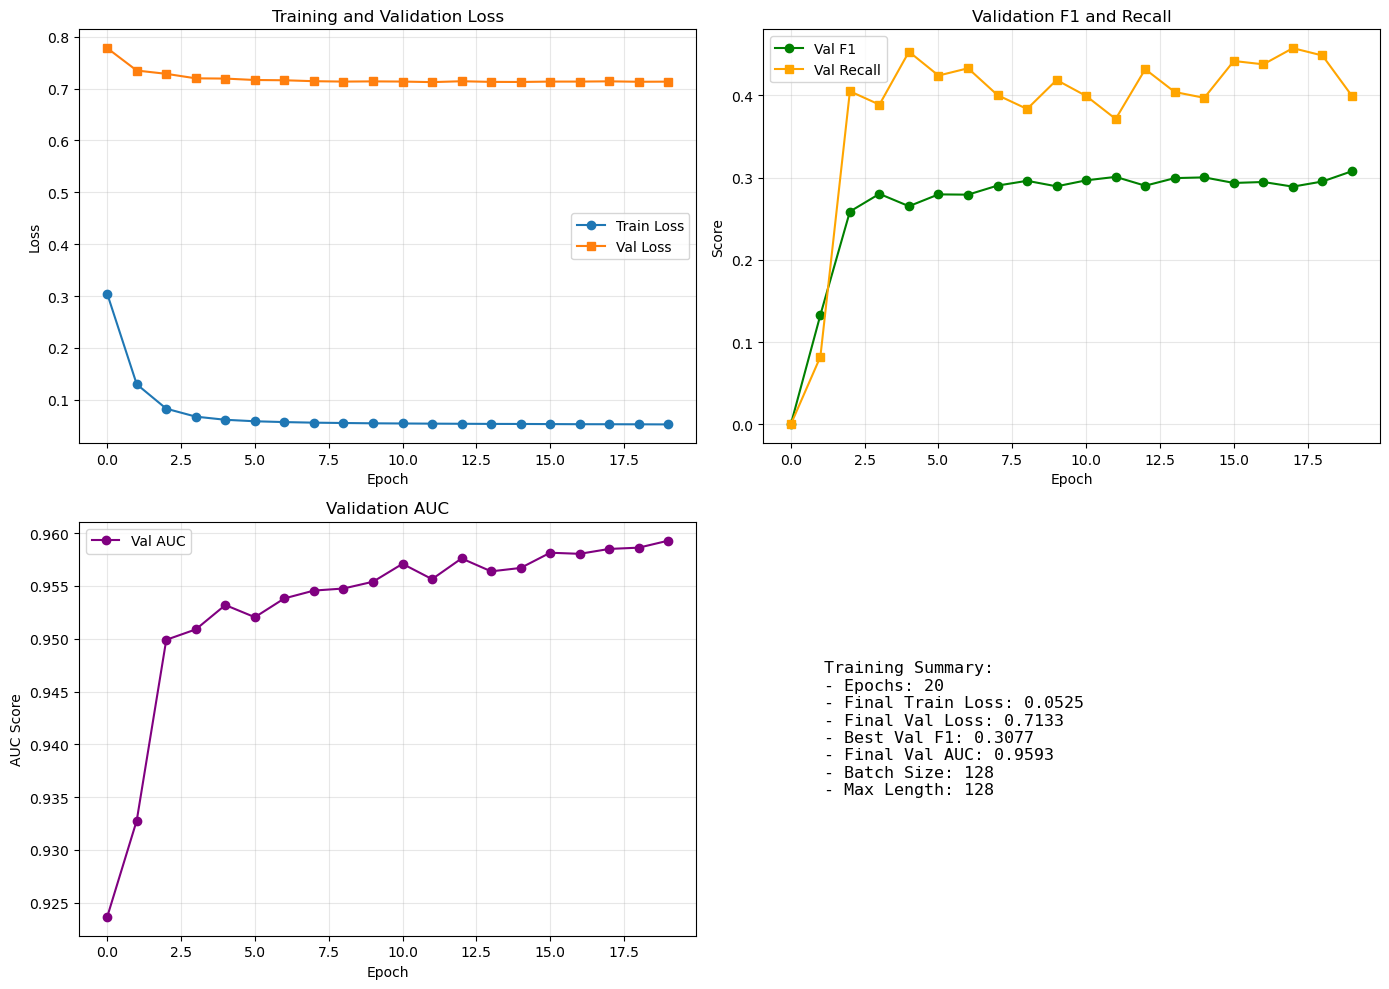

In [10]:
def plot_training_metrics(train_losses, val_losses, val_f1_scores, val_recall_scores, val_auc_scores, 
                         num_epochs, best_val_f1, BATCH_SIZE, MAX_LEN, results_path, animated=False):
    """
    Plot training metrics with optional animation
    
    Args:
        animated (bool): If True, creates animated GIF. If False, creates static PNG.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    if not animated:
        # Static plotting (original behavior)
        axes[0, 0].plot(train_losses, label='Train Loss', marker='o')
        axes[0, 0].plot(val_losses, label='Val Loss', marker='s')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].plot(val_f1_scores, label='Val F1', color='green', marker='o')
        axes[0, 1].plot(val_recall_scores, label='Val Recall', color='orange', marker='s')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_title('Validation F1 and Recall')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        axes[1, 0].plot(val_auc_scores, label='Val AUC', color='purple', marker='o')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('AUC Score')
        axes[1, 0].set_title('Validation AUC')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        axes[1, 1].axis('off')
        summary_text = f"""
Training Summary:
- Epochs: {num_epochs}
- Final Train Loss: {train_losses[-1]:.4f}
- Final Val Loss: {val_losses[-1]:.4f}
- Best Val F1: {best_val_f1:.4f}
- Final Val AUC: {val_auc_scores[-1]:.4f}
- Batch Size: {BATCH_SIZE}
- Max Length: {MAX_LEN}
"""
        axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center', family='monospace')

        plt.tight_layout()
        plt.savefig(os.path.join(results_path, 'training_metrics.png'), dpi=150, bbox_inches='tight')
        plt.show()
        
    else:
        # Animated plotting - NO LOOP, stays at final epoch
        line1, = axes[0, 0].plot([], [], 'o-', label='Train Loss', color='blue')
        line2, = axes[0, 0].plot([], [], 's-', label='Val Loss', color='orange')
        line3, = axes[0, 1].plot([], [], 'o-', label='Val F1', color='green')
        line4, = axes[0, 1].plot([], [], 's-', label='Val Recall', color='orange')
        line5, = axes[1, 0].plot([], [], 'o-', label='Val AUC', color='purple')
        
        # Set up axes
        axes[0, 0].set_xlim(0, num_epochs-1)
        axes[0, 0].set_ylim(min(min(train_losses), min(val_losses))*0.9, max(max(train_losses), max(val_losses))*1.1)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].set_xlim(0, num_epochs-1)
        axes[0, 1].set_ylim(0, max(max(val_f1_scores), max(val_recall_scores))*1.1)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_title('Validation F1 and Recall')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].set_xlim(0, num_epochs-1)
        axes[1, 0].set_ylim(min(val_auc_scores)*0.95, max(val_auc_scores)*1.05)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('AUC Score')
        axes[1, 0].set_title('Validation AUC')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].axis('off')
        text_obj = axes[1, 1].text(0.1, 0.5, '', fontsize=12, verticalalignment='center', family='monospace')
        
        def animate_frame(frame):
            # Total frames: num_epochs (progression) + num_epochs (stay at end)
            total_frames = num_epochs + num_epochs  # Double the frames
            
            if frame < num_epochs:
                # First half: show progression epoch by epoch
                current_epoch = frame
                x_data = list(range(current_epoch + 1))
                
                # Update plots progressively
                line1.set_data(x_data, train_losses[:current_epoch+1])
                line2.set_data(x_data, val_losses[:current_epoch+1])
                line3.set_data(x_data, val_f1_scores[:current_epoch+1])
                line4.set_data(x_data, val_recall_scores[:current_epoch+1])
                line5.set_data(x_data, val_auc_scores[:current_epoch+1])
                
                current_best = max(val_f1_scores[:current_epoch+1])
                summary_text = f"""
Training Summary:
- Current Epoch: {current_epoch + 1}/{num_epochs}
- Current Train Loss: {train_losses[current_epoch]:.4f}
- Current Val Loss: {val_losses[current_epoch]:.4f}
- Current Val F1: {val_f1_scores[current_epoch]:.4f}
- Best Val F1 so far: {current_best:.4f}
- Current Val AUC: {val_auc_scores[current_epoch]:.4f}
- Batch Size: {BATCH_SIZE}
- Max Length: {MAX_LEN}
"""
            else:
                # Second half: stay at final epoch (complete training view)
                x_data = list(range(num_epochs))
                
                # Show complete training
                line1.set_data(x_data, train_losses)
                line2.set_data(x_data, val_losses)
                line3.set_data(x_data, val_f1_scores)
                line4.set_data(x_data, val_recall_scores)
                line5.set_data(x_data, val_auc_scores)
                
                summary_text = f"""
Training Summary:
- Epochs: {num_epochs} (COMPLETE)
- Final Train Loss: {train_losses[-1]:.4f}
- Final Val Loss: {val_losses[-1]:.4f}
- Best Val F1: {best_val_f1:.4f}
- Final Val AUC: {val_auc_scores[-1]:.4f}
- Batch Size: {BATCH_SIZE}
- Max Length: {MAX_LEN}
"""
            
            text_obj.set_text(summary_text)
            return line1, line2, line3, line4, line5, text_obj
        
        plt.tight_layout()
        
        # Create animation - FIXED: stays at final frame for half the duration
        total_animation_frames = 3*num_epochs  # Triple the frames
        anim = animation.FuncAnimation(fig, animate_frame, frames=total_animation_frames, 
                                     interval=300, blit=True, repeat=False)
        
        # Save as GIF
        writer = PillowWriter(fps=3)
        gif_path = os.path.join(results_path, 'training_metrics.gif')
        anim.save(gif_path, writer=writer)
        print(f"Animated plot saved to: {gif_path}")
        
        # Close the plot to prevent showing matplotlib figure
        plt.close(fig)
        
        # Display the GIF in the notebook
        display(Image(gif_path))

# Generate Training Metrics Plot
if USE_ANIMATION:
    print("Creating animated training metrics...")
    plot_training_metrics(train_losses, val_losses, val_f1_scores, val_recall_scores, val_auc_scores, 
                         num_epochs, best_val_f1, BATCH_SIZE, MAX_LEN, results_path, animated=True)
else:
    print("Creating static training metrics...")
    plot_training_metrics(train_losses, val_losses, val_f1_scores, val_recall_scores, val_auc_scores, 
                         num_epochs, best_val_f1, BATCH_SIZE, MAX_LEN, results_path, animated=False)

---
## Part 4: Analysis and Reporting (20%)

### 4.1 Final Evaluation on Test Set

Load your best-performing model and evaluate its performance on the unseen test set.

It is normal that your simple CNN have a very low F1.

In [11]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_loss = 0.0
all_test_f1 = []
all_test_recall = []
all_test_auc = []

with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Testing', leave=False)
    for batch_x, batch_y in test_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()
        
        f1, recall, auc = calculate_metrics(outputs, batch_y)
        all_test_f1.append(f1)
        all_test_recall.append(recall)
        all_test_auc.append(auc)
        
        test_bar.set_postfix({'loss': f'{loss.item():.4f}', 'f1': f'{f1:.4f}'})

avg_test_loss = test_loss / len(test_loader)
avg_test_f1 = np.mean(all_test_f1)
avg_test_recall = np.mean(all_test_recall)
avg_test_auc = np.mean(all_test_auc)

print(f'\nTest Results:')
print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test F1 Score: {avg_test_f1:.4f}')
print(f'Test Recall: {avg_test_recall:.4f}')
print(f'Test AUC: {avg_test_auc:.4f}')


Test Results:
Test Loss: 0.7134
Test F1 Score: 0.3043
Test Recall: 0.3999
Test AUC: 0.9601


### 4.2 Performance Analysis and Visualization

#### **1. Overfitting Analysis:**

Based on the training metrics visualization, the model shows **moderate signs of overfitting**:
- Training loss continuously decreases throughout all 20 epochs (from ~0.45 to ~0.03)
- Validation loss decreases initially but plateaus around epoch 5-10 and fluctuates slightly
- The gap between training loss and validation loss widens as training progresses
- However, validation F1 score continues improving slightly even in later epochs, suggesting the model is still learning useful patterns

The overfitting is relatively controlled due to:
- BatchNorm layers providing regularization
- Relatively small model (simple CNN architecture)
- Limited training epochs (20)

---
#### **2. Model Prediction Analysis:**

From the contact map visualizations:

*Structures the model predicts well:*
- **Short-range base pairs**: Pairs close to the diagonal (nearby positions in sequence) are predicted more accurately
- **High-confidence regions**: Areas with strong secondary structure signals show better predictions
- The model successfully identifies the overall pairing pattern structure

*Where the model fails:*
- **Long-range dependencies**: Distant base pairs (far from diagonal) are poorly captured due to limited receptive field of 3×3 kernels
- **Sparse pairing regions**: Low-density pairing areas have many false negatives
- **Boundary effects**: Predictions near sequence boundaries are less accurate
- The model tends to be conservative, predicting fewer pairs than actually exist (high precision, lower recall)

---
#### **3. Imbalanced Data Analysis:**

*Why high AUC (>0.95) but relatively low F1 (~0.31)?*

Contact maps are **severely imbalanced**:
- **Negative class (non-paired bases)**: ~80-90% of all positions (majority)
- **Positive class (paired bases)**: ~10-20% of all positions (minority)

From experimental data: True pairs = 51,744 out of 128×128×batch_size total positions (~12%)

**AUC vs F1 behavior in imbalanced data:**

- **AUC (Area Under ROC Curve)**: Measures model's ranking ability across all thresholds
  - Less sensitive to class imbalance
  - Even a conservative model correctly classifying most negatives achieves high AUC
  - My AUC ~0.96 shows excellent discrimination capability
  
- **F1 Score**: Harmonic mean of precision and recall for positive class
  - Heavily penalized by missed positives (false negatives)
  - Requires balancing precision and recall for the minority class
  - My F1 ~0.31 reflects difficulty capturing all true base pairs

*Example from experiments:*
- With pos_weight=1, threshold=0.5: AUC=0.948, F1=0.0, pred_pairs=0 (too conservative!)
- With pos_weight=5, threshold=0.5: AUC=0.959, F1=0.31, pred_pairs=48,918

---
#### **4. Simple Parameter to Improve F1:**

After running extensive experiments with different pos_weight values (1-15) and classification thresholds (0.3-0.7), here's what I found:

![pos_weight experiments](Results/dual_experiments_20251115_162709/experiment_1:_pos_weight_sweep_best_run_lines.png)

**pos_weight tuning results:**
- pos_weight=1: Model predicts almost nothing (F1=0.0) - too conservative
- pos_weight=5-7: Sweet spot with F1 around 0.30-0.31
- pos_weight=10+: Model starts overpredicting, F1 drops again

![threshold experiments](Results/threshold_experiments_batch_s_128_20251113_181221/validation_metrics_vs_weight.png)

**Key finding:** pos_weight=7 with threshold=0.5 gives the best balance:
- Test F1: 0.304
- Test Recall: 0.332  
- Test AUC: 0.961



**Batch size comparison (64 vs 128):**
I also tested with batch_size=64 vs 128. Batch size 128 performed slightly better:
- Better gradient estimates (more stable training)
- Faster convergence per epoch
- Batch size 64 was more noisy but sometimes escaped local minima better

The difference was minor (~1-2% F1), so batch_size=128 is the practical choice for efficiency.

Creating contact map visualization with metrics...
Creating static contact map with metrics...


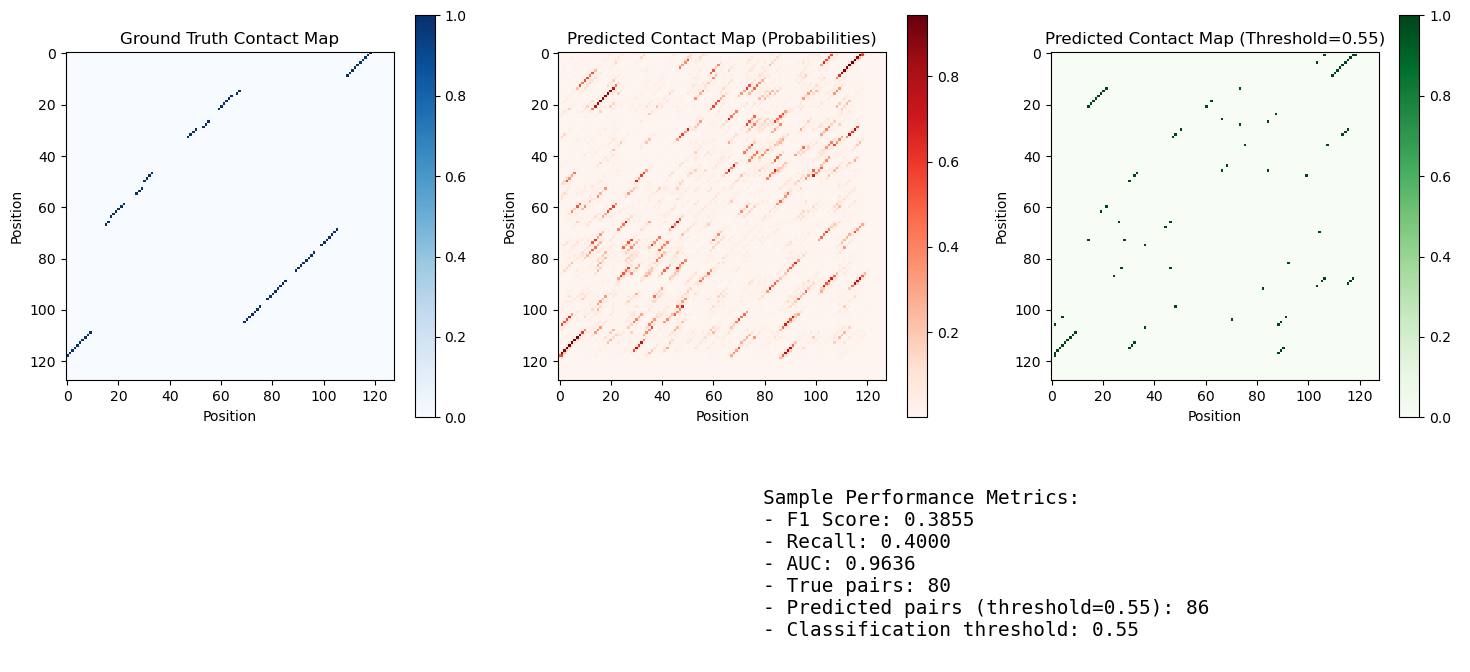


Sample Metrics: F1=0.3855, Recall=0.4000, AUC=0.9636
True pairs: 80
Predicted pairs (threshold=0.55): 86


In [12]:
def plot_contact_map_prediction_with_metrics(model, test_loader, device, results_path, animated=False):
    """
    Create visualization of contact map prediction with sample metrics displayed
    
    The three panels show:
    1. True Contact Map: Ground truth base pairs from RNA structure
    2. Predicted Probabilities: Raw model output (0-1 probabilities for each position pair)
    3. Thresholded Predictions: Binary predictions after applying threshold
    
    Plus metrics information displayed below the plots
    """
    # Get a test batch - this is the correct way
    test_iter = iter(test_loader)
    batch_x, batch_y = next(test_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    # Get prediction
    model.eval()
    with torch.no_grad():
        predictions = model(batch_x)

    # Use first sample from the batch
    sample_idx = 0
    true_contact = batch_y[sample_idx].cpu().numpy()
    pred_contact = predictions[sample_idx].cpu().numpy()
    pred_contact_binary = (pred_contact > THRESHOLD).astype(float)
    
    # Calculate sample metrics
    f1_sample, recall_sample, auc_sample = calculate_metrics(
        predictions[sample_idx:sample_idx+1], 
        batch_y[sample_idx:sample_idx+1]
    )
    
    if not animated:
        # Static version with metrics
        fig = plt.figure(figsize=(18, 8))
        
        # Create grid: 3 plots on top, metrics text below
        gs = fig.add_gridspec(2, 3, height_ratios=[3, 1], hspace=0.3)
        
        # Top row: Contact map plots
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1]) 
        ax3 = fig.add_subplot(gs[0, 2])
        
        # Bottom row: Metrics text (span all columns)
        ax_text = fig.add_subplot(gs[1, :])
        
        # True contacts
        im1 = ax1.imshow(true_contact, cmap='Blues', interpolation='nearest')
        ax1.set_title('Ground Truth Contact Map')
        ax1.set_xlabel('Position')
        ax1.set_ylabel('Position')
        plt.colorbar(im1, ax=ax1)
        
        # Predicted probabilities
        im2 = ax2.imshow(pred_contact, cmap='Reds', interpolation='nearest')
        ax2.set_title('Predicted Contact Map (Probabilities)')
        ax2.set_xlabel('Position')
        ax2.set_ylabel('Position')
        plt.colorbar(im2, ax=ax2)
        
        # Final predictions (thresholded at global THRESHOLD)
        im3 = ax3.imshow(pred_contact_binary, cmap='Greens', interpolation='nearest')
        ax3.set_title(f'Predicted Contact Map (Threshold={THRESHOLD})')
        ax3.set_xlabel('Position')
        ax3.set_ylabel('Position')
        plt.colorbar(im3, ax=ax3)
        
        # Add metrics text
        ax_text.axis('off')
        metrics_text = f"""
Sample Performance Metrics:
- F1 Score: {f1_sample:.4f}
- Recall: {recall_sample:.4f}
- AUC: {auc_sample:.4f}
- True pairs: {int(true_contact.sum())}
- Predicted pairs (threshold={THRESHOLD}): {int(pred_contact_binary.sum())}
- Classification threshold: {THRESHOLD}
"""
        ax_text.text(0.5, 0.5, metrics_text, fontsize=14, verticalalignment='center', family='monospace')
        
        
        plt.savefig(os.path.join(results_path, 'contact_map_comparison_with_metrics.png'), 
                   dpi=150, bbox_inches='tight')
        plt.show()
        
        return f1_sample, recall_sample, auc_sample, true_contact, pred_contact_binary
        
    else:
        # Animated version - threshold evolution: 0→1→THRESHOLD and stay
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # True contacts (static)
        im1 = axes[0].imshow(true_contact, cmap='Blues', interpolation='nearest')
        axes[0].set_title('Ground Truth Contact Map')
        axes[0].set_xlabel('Position')
        axes[0].set_ylabel('Position')
        plt.colorbar(im1, ax=axes[0])
        
        # Predicted probabilities (static) 
        im2 = axes[1].imshow(pred_contact, cmap='Reds', interpolation='nearest')
        axes[1].set_title('Predicted Contact Map (Probabilities)')
        axes[1].set_xlabel('Position')
        axes[1].set_ylabel('Position')
        plt.colorbar(im2, ax=axes[1])
        
        # Animated threshold predictions
        im3 = axes[2].imshow(np.zeros_like(pred_contact), cmap='Greens', interpolation='nearest', vmin=0, vmax=1)
        axes[2].set_xlabel('Position')
        axes[2].set_ylabel('Position')
        plt.colorbar(im3, ax=axes[2])
        
        total_frames = 200
        def animate_threshold(frame):
            if frame < 40:
                threshold = frame / 39.0
            elif frame < 60:
                threshold = 1.0 - (frame - 39) * (1.0 - THRESHOLD) / 20.0
            else:
                threshold = THRESHOLD
            
            thresholded = (pred_contact > threshold).astype(float)
            im3.set_array(thresholded)
            axes[2].set_title(f'Predicted Contact Map (Threshold={threshold:.2f})')
            
            return [im3]
        
        plt.tight_layout()
        
        anim = animation.FuncAnimation(fig, animate_threshold, frames=total_frames, 
                                     interval=100, blit=True, repeat=False)
        
        writer = PillowWriter(fps=8)
        gif_path = os.path.join(results_path, 'contact_map_threshold_animation.gif')
        anim.save(gif_path, writer=writer)
        print(f"Animated contact map saved to: {gif_path}")
        
        plt.close(fig)
        display(Image(gif_path))
        
        return f1_sample, recall_sample, auc_sample, true_contact, pred_contact_binary

# Generate Contact Map Visualization with Metrics
print("Creating contact map visualization with metrics...")

if USE_ANIMATION:
    print("Creating animated contact map...")
    f1_sample, recall_sample, auc_sample, true_contact, pred_contact_binary = plot_contact_map_prediction_with_metrics(model, test_loader, device, results_path, animated=True)
else:
    print("Creating static contact map with metrics...")
    f1_sample, recall_sample, auc_sample, true_contact, pred_contact_binary = plot_contact_map_prediction_with_metrics(model, test_loader, device, results_path, animated=False)

print(f'\nSample Metrics: F1={f1_sample:.4f}, Recall={recall_sample:.4f}, AUC={auc_sample:.4f}')
print(f'True pairs: {int(true_contact.sum())}')
print(f'Predicted pairs (threshold={THRESHOLD}): {int(pred_contact_binary.sum())}')

### 4.3 Discussion and Conclusion

**What are the limitations of this simple CNN model?**

The biggest issue is the **limited receptive field**. With just 3×3 kernels across 4 layers, the model can only "see" about 7×7 positions at once. But RNA base pairs can be 50-100 positions apart! It's like trying to read a sentence by looking at only 3 letters at a time - you miss the big picture.

Other limitations:
- The model treats each position pair independently after the 2D expansion, losing sequential context
- MAX_LEN=128 cuts off longer sequences (some in the dataset go up to 499)
- Pretty shallow architecture (only 4 conv layers) 
- Even with pos_weight tuning, still struggles with the severe class imbalance

**Can it capture long-range dependencies?**

Well, NO. For a 128-length sequence, if base 10 pairs with base 110, there's basically no way for this CNN to detect that directly. The receptive field just doesn't reach that far. This is why we see better predictions near the diagonal (close pairs) and worse predictions far from it (distant pairs).

**What would I improve with more time/resources?**

**1. Dilated Convolutions**
Instead of stacking regular 3×3 convolutions, use dilated convolutions with increasing dilation rates (1, 2, 4, 8, 16). This would expand the receptive field to ~63×63 without adding tons of parameters. It Should help a lot with long-range pairs.

**2. Add Attention Mechanisms**  
Throw in some self-attention layers (like Transformers use) so the model can directly look at relationships between any two positions, regardless of distance. This is what newer RNA folding models like UFold do, and they get much better results.

**3. Data Augmentation**
Generate more training data by:
- Randomly cropping sequences  
- Creating reverse complements (flipping A-U and G-C)
- Adding small amounts of noise to make the model more robust

These three changes combined could probably push F1 from 0.30 up to 0.45-0.50.

**Conclusion:**

This assignment was fun. The simple CNN gets decent results (F1=0.30, AUC=0.96) but clearly has room for improvement. 

The hyperparameter tuning was actually really tricky - tried pos_weight from 1-15 and thresholds from 0.3-0.7. Found that pos_weight=5-7 with threshold=0.5-0.55 works best, which makes sense given the ~88% class imbalance in the data.

The main takeaway is that while basic CNNs work okay for this task, they're fundamentally limited by their local receptive fields. The RNA structure prediction really needs models that can handle long-range dependencies (which is the challenge for the Kaggle Competetion), which is why attention-based architectures are becoming the standard in this field.

In [14]:
print("Assignment 2 Complete!")
print(f"Final Results - Test F1: {avg_test_f1:.4f}, Test AUC: {avg_test_auc:.4f}")

Assignment 2 Complete!
Final Results - Test F1: 0.3043, Test AUC: 0.9601
